# Stage 3: NLOS Ranging Error Prediction (CNN Baseline)
## Multi-Model Pipeline — Distance Correction via Single-Bounce Exploitation

**Purpose**: Given an NLOS signal where the single-bounce path is identifiable (Stage 2 = Correctable), predict the **ranging error** in meters — how much the hardware's reported distance overshoots the true TX→RX distance.

**Target**: `ranging_error = Distance_hardware - d_direct` (per-sample, varies due to channel conditions and noise)

**Correction**: `d_corrected = d_hardware - predicted_error`

**Architecture**: Frozen CNN_Classifier encoder → 128-dim CNN embeddings → Random Forest Regressor

**Data filtering**: Only correctable samples (bounce dominance ≥ threshold AND ≤ 2 peaks) — same mixture filter as Stage 2 labels.

**Pipeline**: Stage 1 (CNN → LOS/NLOS) → Stage 2 (CNN embeddings → RF → single-bounce identification) → **Stage 3 (CNN embeddings → RF → ranging error)**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from scipy.signal import find_peaks
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import os

# ==========================================
# CONFIGURATION
# ==========================================
CONFIG = {
    # ROI alignment (same as Stage 1/2)
    "search_start": 740,
    "search_end": 810,
    # Peak detection — morphological CIR quality (same as Stage 2)
    "peak_prominence": 0.20,
    "peak_min_distance": 5,
    "dominant_path_max_peaks": 2,
    # Geometric bounce dominance (same as Stage 2)
    "bounce_search_window": 3,
    "dominance_threshold": 0.50,
    # Random Forest Regressor
    "n_estimators": 200,
    "max_depth": None,
    "min_samples_split": 5,
    "min_samples_leaf": 2,
    # Split
    "test_ratio": 0.30,
    "seed": 42,
}

np.random.seed(CONFIG["seed"])
print(f"Config: {CONFIG}")
print(f"\nTarget: ranging_error = Distance_hardware - d_direct (meters)")
print(f"Filter: correctable only (bounce dominance >= {CONFIG['dominance_threshold']:.0%} AND num_peaks <= {CONFIG['dominant_path_max_peaks']})")
print(f"Model: 128-dim CNN embeddings → RF Regressor ({CONFIG['n_estimators']} trees)")

Config: {'search_start': 740, 'search_end': 810, 'peak_prominence': 0.2, 'peak_min_distance': 5, 'dominant_path_max_peaks': 2, 'bounce_search_window': 3, 'dominance_threshold': 0.5, 'n_estimators': 200, 'max_depth': None, 'min_samples_split': 5, 'min_samples_leaf': 2, 'test_ratio': 0.3, 'seed': 42}

Target: ranging_error = Distance_hardware - d_direct (meters)
Filter: correctable only (bounce dominance >= 50% AND num_peaks <= 2)
Model: 128-dim CNN embeddings → RF Regressor (200 trees)


---
## Section 2: Data Loading & Correctable Filtering

1. Load NLOS samples from the combined dataset
2. Compute bounce dominance + peak count (same mixture criteria as Stage 2)
3. **Filter**: keep only correctable samples (both conditions met)
4. Compute per-sample ranging error target: `Distance - d_direct`

Stage 3 only trains on correctable samples because these are the signals where the single-bounce is identifiable — Stage 3 would give unreliable predictions on challenging signals it was never trained on. Stage 2 gates inference to prevent this.

In [2]:
# ==========================================
# ROI ALIGNMENT (reused from Stage 1/2)
# ==========================================
def get_roi_alignment(sig, search_start=CONFIG["search_start"],
                      search_end=CONFIG["search_end"]):
    """Find leading edge by backtracking from peak."""
    region = sig[search_start:search_end]
    if len(region) == 0:
        return np.argmax(sig)

    peak_local = np.argmax(region)
    peak_idx = search_start + peak_local
    peak_val = sig[peak_idx]

    noise_section = sig[:search_start]
    if len(noise_section) > 10:
        noise_mean = np.mean(noise_section)
        noise_std = np.std(noise_section)
        threshold = max(noise_mean + 3 * noise_std, 0.05 * peak_val)
    else:
        threshold = 0.05 * peak_val

    leading_edge = peak_idx
    for i in range(peak_idx, max(search_start - 20, 0), -1):
        if sig[i] < threshold:
            leading_edge = i + 1
            break

    return leading_edge


# ==========================================
# LOAD NLOS DATA + FILTER TO CORRECTABLE (using pre-labeled CSV)
# ==========================================
def load_correctable_nlos(filepath="../dataset/channels/combined_uwb_dataset.csv"):
    """
    Load NLOS samples filtered to correctable using pre-labeled columns
    (is_correctable, num_peaks, bounce_dominance) from the dataset CSV.
    """
    print(f"Loading: {filepath}")
    df = pd.read_csv(filepath)

    cir_cols = sorted(
        [c for c in df.columns if c.startswith('CIR')],
        key=lambda x: int(x.replace('CIR', ''))
    )

    # Filter to correctable NLOS using pre-labeled column
    corr_df = df[(df["Label"] == 1) & (df["is_correctable"] == 1)].reset_index(drop=True)
    total_nlos = (df["Label"] == 1).sum()
    print(f"  Total samples: {len(df)}, NLOS: {total_nlos}, Correctable: {len(corr_df)} ({100*len(corr_df)/total_nlos:.1f}%)")

    raw_sigs = []
    leading_edges = []
    d_hardware_list = []
    d_direct_list = []
    d_bounce_list = []
    source_files = []

    for idx, row in corr_df.iterrows():
        sig = pd.to_numeric(row[cir_cols], errors='coerce').fillna(0).astype(float).values

        # RXPACC normalization
        rxpacc_col = 'RXPACC' if 'RXPACC' in row.index else 'RX_PACC'
        rxpacc = float(row.get(rxpacc_col, 128.0))
        if rxpacc > 0:
            sig = sig / rxpacc

        le = get_roi_alignment(sig)
        raw_sigs.append(sig)
        leading_edges.append(le)

        d_hardware_list.append(float(row['Distance']))
        d_direct_list.append(float(row['d_direct']))
        d_bounce_list.append(float(row['d_bounce']))
        source_files.append(str(row.get('Source_File', '')))

    leading_edges = np.array(leading_edges)
    d_hardware = np.array(d_hardware_list, dtype=float)
    d_direct = np.array(d_direct_list, dtype=float)
    d_bounce = np.array(d_bounce_list, dtype=float)

    # Ranging error target
    ranging_error = d_hardware - d_direct

    # Scenario groups
    groups = []
    for sf in source_files:
        match = re.search(r'([\d.]+)m_nlos', sf)
        groups.append(match.group(1) + 'm' if match else 'unknown')
    groups = np.array(groups)

    print(f"\n  Ranging error target (Distance - d_direct):")
    print(f"    Mean: {ranging_error.mean():.3f}m, Std: {ranging_error.std():.3f}m")
    print(f"    Min: {ranging_error.min():.3f}m, Max: {ranging_error.max():.3f}m")
    print(f"\n  Per scenario:")
    for g in sorted(set(groups)):
        mask = groups == g
        re_g = ranging_error[mask]
        print(f"    {g}: n={int(mask.sum())}, RE mean={re_g.mean():.3f}m, std={re_g.std():.3f}m")

    return (np.array(raw_sigs), leading_edges,
            d_hardware, d_direct, d_bounce, ranging_error, groups)


raw_sigs, leading_edges, d_hardware, d_direct, d_bounce, ranging_error, groups = load_correctable_nlos()


Loading: ../dataset/channels/combined_uwb_dataset.csv
  Total samples: 3600, NLOS: 1800, Correctable: 506 (28.1%)

  Ranging error target (Distance - d_direct):
    Mean: 1.700m, Std: 2.162m
    Min: -0.070m, Max: 7.470m

  Per scenario:
    16.09m: n=457, RE mean=1.825m, std=2.239m
    9.54m: n=49, RE mean=0.533m, std=0.193m


---
## Section 3: Target Visualization

Visualize the ranging error distribution for correctable samples:
- Overall histogram
- Per-scenario breakdown
- d_hardware vs d_direct scatter

C:\Users\preca\AppData\Local\Temp\ipykernel_5240\3489694969.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=unique_groups, patch_artist=True)


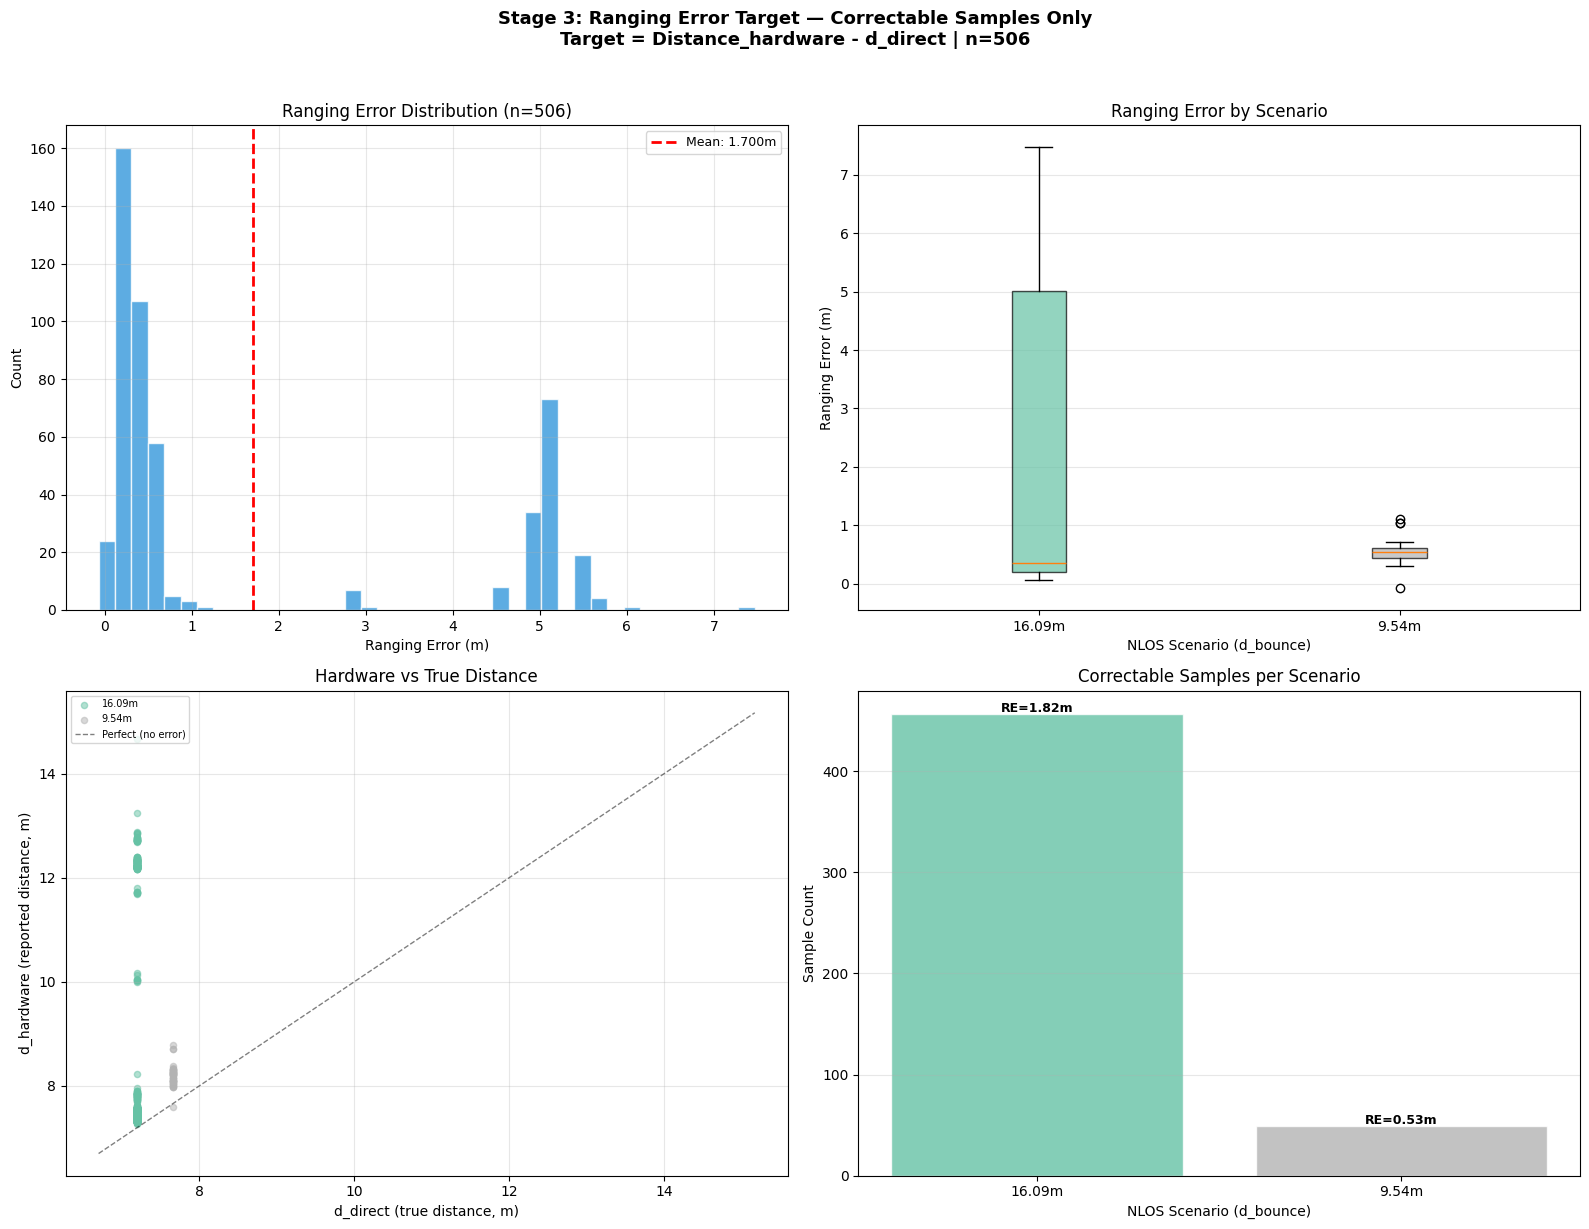

In [3]:
# ==========================================
# TARGET VISUALIZATION
# ==========================================
fig, axs = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.35, wspace=0.3)

unique_groups = sorted(set(groups))
colors = plt.cm.Set2(np.linspace(0, 1, len(unique_groups)))
group_colors = {g: colors[i] for i, g in enumerate(unique_groups)}

# 1. Ranging error histogram (overall)
ax = axs[0, 0]
ax.hist(ranging_error, bins=40, color='#3498db', edgecolor='white', alpha=0.8)
ax.axvline(ranging_error.mean(), color='red', ls='--', lw=2,
           label=f'Mean: {ranging_error.mean():.3f}m')
ax.set_xlabel('Ranging Error (m)')
ax.set_ylabel('Count')
ax.set_title(f'Ranging Error Distribution (n={len(ranging_error)})')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# 2. Per-scenario box plot
ax = axs[0, 1]
box_data = [ranging_error[groups == g] for g in unique_groups]
bp = ax.boxplot(box_data, labels=unique_groups, patch_artist=True)
for patch, g in zip(bp['boxes'], unique_groups):
    patch.set_facecolor(group_colors[g])
    patch.set_alpha(0.7)
ax.set_xlabel('NLOS Scenario (d_bounce)')
ax.set_ylabel('Ranging Error (m)')
ax.set_title('Ranging Error by Scenario')
ax.grid(True, alpha=0.3, axis='y')

# 3. d_hardware vs d_direct scatter
ax = axs[1, 0]
for g in unique_groups:
    mask = groups == g
    ax.scatter(d_direct[mask], d_hardware[mask],
              c=[group_colors[g]], s=20, alpha=0.5, label=g)
lims = [min(d_direct.min(), d_hardware.min()) - 0.5,
        max(d_direct.max(), d_hardware.max()) + 0.5]
ax.plot(lims, lims, 'k--', lw=1, alpha=0.5, label='Perfect (no error)')
ax.set_xlabel('d_direct (true distance, m)')
ax.set_ylabel('d_hardware (reported distance, m)')
ax.set_title('Hardware vs True Distance')
ax.legend(fontsize=7, loc='upper left')
ax.grid(True, alpha=0.3)

# 4. Per-scenario sample count + mean error
ax = axs[1, 1]
counts = [int(np.sum(groups == g)) for g in unique_groups]
means = [ranging_error[groups == g].mean() for g in unique_groups]
bars = ax.bar(unique_groups, counts, color=[group_colors[g] for g in unique_groups],
              edgecolor='white', alpha=0.8)
ax.set_xlabel('NLOS Scenario (d_bounce)')
ax.set_ylabel('Sample Count')
ax.set_title('Correctable Samples per Scenario')
ax.grid(True, alpha=0.3, axis='y')
for i, (bar, m) in enumerate(zip(bars, means)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'RE={m:.2f}m', ha='center', fontsize=9, fontweight='bold')

plt.suptitle(f'Stage 3: Ranging Error Target — Correctable Samples Only\n'
             f'Target = Distance_hardware - d_direct | n={len(ranging_error)}',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Section 4: Frozen CNN Encoder — Embedding Extraction

Frozen CNN_Classifier encoder from Stage 1. Extracts 128-dim GAP embeddings for correctable NLOS samples.

**Key**: No FP_AMPL conditioning — CNN processes raw CIR only. Global Average Pooling (GAP) over conv feature maps produces the 128-dim embedding.

**Input format**: Channels-first `(B, 1, 60)` for Conv1d.

In [4]:
import torch
import torch.nn as nn


class CNN_Classifier(nn.Module):
    """
    1D-CNN WITHOUT FP_AMPL conditioning.

    CIR passes through 3 conv blocks with BatchNorm + GAP to produce a
    128-dim embedding. Classifier operates on CNN features only (128-dim).
    No FP projection — identical conv encoder to CNN+FP.
    """
    def __init__(self, input_channels=1, embedding_size=128, dropout=0.4):
        super().__init__()
        self.embedding_size = embedding_size

        # 1D-CNN encoder
        self.encoder = nn.Sequential(
            nn.Conv1d(input_channels, 16, kernel_size=5, padding=2),
            nn.BatchNorm1d(16), nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=5, padding=2, stride=2),
            nn.BatchNorm1d(32), nn.ReLU(),
            nn.Conv1d(32, embedding_size, kernel_size=3, padding=1, stride=2),
            nn.BatchNorm1d(embedding_size), nn.ReLU(),
        )
        self.gap = nn.AdaptiveAvgPool1d(1)

        # Classifier: embedding_size → 32 → 1
        self.classifier = nn.Sequential(
            nn.Linear(embedding_size, 32),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def _encode_cir(self, x):
        """CNN encoder: (B, 1, 60) -> (B, embedding_size)."""
        features = self.encoder(x)
        return self.gap(features).squeeze(-1)

    def forward(self, x, return_dynamics=False):
        cnn_embed = self._encode_cir(x)  # (B, 128)
        pred = self.classifier(cnn_embed)

        if return_dynamics:
            features = self.encoder(x)  # (B, 128, 15)
            return pred, features
        return pred

    def embed(self, x):
        """Return 128-dim CNN embedding for Stage 2/3 compatibility."""
        return self._encode_cir(x)


print(f"CNN_Classifier defined: {sum(p.numel() for p in CNN_Classifier().parameters()):,} params")
print(f"  Embedding dim: 128 (GAP over conv feature maps)")
print(f"  FP_AMPL conditioning: NONE (CIR only)")

CNN_Classifier defined: 19,617 params
  Embedding dim: 128 (GAP over conv feature maps)
  FP_AMPL conditioning: NONE (CIR only)


In [5]:
# ==========================================
# LOAD FROZEN STAGE 1 ENCODER & EXTRACT EMBEDDINGS
# ==========================================
_saved = torch.load("stage1_cnn_config.pt", map_location="cpu", weights_only=False)
STAGE1_CONFIG = _saved["config"]
print("STAGE1_CONFIG loaded from stage1_cnn_config.pt")
print(STAGE1_CONFIG)

EMBEDDING_DIM = STAGE1_CONFIG['embedding_size']  # 128
EMBEDDING_NAMES = [f'CNN_f{i}' for i in range(EMBEDDING_DIM)]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def preprocess_cir_for_cnn(sig, leading_edge):
    """Convert a single RXPACC-normalized CIR + leading edge to 60-sample window (channels-first)."""
    PRE = STAGE1_CONFIG['pre_crop']
    TOTAL = STAGE1_CONFIG['total_len']
    start = max(0, leading_edge - PRE)
    end = start + TOTAL
    if end > len(sig):
        end = len(sig)
        start = max(0, end - TOTAL)
    crop = sig[start:end]
    if len(crop) < TOTAL:
        crop = np.pad(crop, (0, TOTAL - len(crop)), mode='constant')
    local_min, local_max = np.min(crop), np.max(crop)
    rng = local_max - local_min
    crop = (crop - local_min) / rng if rng > 0 else np.zeros(TOTAL)
    return crop


# Load frozen Stage 1 encoder (CNN_Classifier)
cnn_encoder = CNN_Classifier(
    input_channels=STAGE1_CONFIG['input_channels'],
    embedding_size=STAGE1_CONFIG['embedding_size'],
    dropout=STAGE1_CONFIG['dropout'],
).to(device)

checkpoint_path = 'stage1_cnn_best.pt'
cnn_encoder.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=True))
cnn_encoder.eval()
for param in cnn_encoder.parameters():
    param.requires_grad = False

print(f"\nLoaded frozen Stage 1 encoder from {checkpoint_path}")
print(f"  Architecture: CNN_Classifier (embedding_size={STAGE1_CONFIG['embedding_size']})")
print(f"  Device: {device}")
print(f"  Parameters: {sum(p.numel() for p in cnn_encoder.parameters()):,} (all frozen)")
print(f"  Embedding dim: {EMBEDDING_DIM} (GAP over conv feature maps)")
print(f"  FP_AMPL conditioning: NONE (CIR only)")

# Extract 128-dim CNN embeddings for correctable NLOS samples
print(f"\nExtracting {EMBEDDING_DIM}-dim embeddings for {len(raw_sigs)} correctable samples...")

cir_sequences = []
for i in range(len(raw_sigs)):
    crop = preprocess_cir_for_cnn(raw_sigs[i], leading_edges[i])
    cir_sequences.append(crop)

# CNN uses channels-first: (B, 1, 60)
cir_tensor = torch.tensor(
    np.array(cir_sequences).reshape(-1, 1, STAGE1_CONFIG['total_len']),
    dtype=torch.float32
).to(device)

all_embeddings = []
with torch.no_grad():
    for i in range(0, len(cir_tensor), 256):
        batch_cir = cir_tensor[i:i+256]
        emb = cnn_encoder.embed(batch_cir)  # (batch, 128)
        all_embeddings.append(emb.cpu().numpy())

embeddings = np.vstack(all_embeddings)

print(f"  Embeddings shape: {embeddings.shape}")
print(f"  Embedding stats — mean: {embeddings.mean():.4f}, std: {embeddings.std():.4f}")
print(f"\nReady for Random Forest Regressor training on {EMBEDDING_DIM}-dim CNN embeddings.")

STAGE1_CONFIG loaded from stage1_cnn_config.pt
{'pre_crop': 10, 'post_crop': 50, 'total_len': 60, 'search_start': 740, 'search_end': 810, 'embedding_size': 128, 'input_channels': 1, 'dropout': 0.4, 'batch_size': 64, 'max_epochs': 50, 'lr': 0.001, 'weight_decay': 0.0001, 'warmup_epochs': 3, 'patience': 10, 'grad_clip': 1.0, 'val_ratio': 0.15, 'test_ratio': 0.15, 'seed': 42}

Loaded frozen Stage 1 encoder from stage1_cnn_best.pt
  Architecture: CNN_Classifier (embedding_size=128)
  Device: cuda
  Parameters: 19,617 (all frozen)
  Embedding dim: 128 (GAP over conv feature maps)
  FP_AMPL conditioning: NONE (CIR only)

Extracting 128-dim embeddings for 506 correctable samples...
  Embeddings shape: (506, 128)
  Embedding stats — mean: 0.3862, std: 0.2235

Ready for Random Forest Regressor training on 128-dim CNN embeddings.


---
## Section 5: Random Forest Regressor

**Architecture**: Frozen CNN_Classifier encoder → **128-dim CNN embeddings** → Random Forest Regressor

- **Input**: 128-dim CNN embeddings (GAP over conv feature maps, no FP conditioning)
- **Target**: Ranging error in meters (`Distance_hardware - d_direct`)
- **At inference**: No ground truth needed — the RF predicts error from embeddings alone, Stage 2 gates which samples reach here

In [6]:
# ==========================================
# RANDOM FOREST REGRESSOR TRAINING (70/30 SPLIT)
# ==========================================
X_all = embeddings
y_all = ranging_error

FEATURE_DIM = X_all.shape[1]

print(f"Input features: {FEATURE_DIM} dimensions (CNN embeddings from frozen Stage 1)")
print(f"Target: ranging error (Distance - d_direct), meters")
print(f"Samples: {len(X_all)} correctable NLOS")

# 70/30 split — stratify by scenario group for balanced representation
X_train, X_test, y_train, y_test, g_train, g_test, dh_train, dh_test, dd_train, dd_test = train_test_split(
    X_all, y_all, groups, d_hardware, d_direct,
    test_size=CONFIG["test_ratio"],
    stratify=groups,
    random_state=CONFIG["seed"]
)

print(f"\nSplit (70/30):")
print(f"  Train: {len(X_train)}")
print(f"  Test:  {len(X_test)}")
for g in sorted(set(groups)):
    n_tr = int(np.sum(g_train == g))
    n_te = int(np.sum(g_test == g))
    print(f"    {g}: train={n_tr}, test={n_te}")

# Compute inverse-frequency sample weights (balance scenario representation)
unique_groups, group_counts = np.unique(g_train, return_counts=True)
group_weight_map = {g: len(g_train) / (len(unique_groups) * c) for g, c in zip(unique_groups, group_counts)}
sample_weights = np.array([group_weight_map[g] for g in g_train])
print("Sample weights (inverse-frequency):")
for g in sorted(group_weight_map):
    print(f"  {g}: weight={group_weight_map[g]:.3f} (n={dict(zip(unique_groups, group_counts))[g]})")

# Train Random Forest Regressor
rf_model = RandomForestRegressor(
    n_estimators=CONFIG["n_estimators"],
    max_depth=CONFIG["max_depth"],
    min_samples_split=CONFIG["min_samples_split"],
    min_samples_leaf=CONFIG["min_samples_leaf"],
    random_state=CONFIG["seed"],
    n_jobs=-1,
)
rf_model.fit(X_train, y_train, sample_weight=sample_weights)

# Evaluate
y_pred_train = rf_model.predict(X_train)
y_pred_test = rf_model.predict(X_test)

train_mae = mean_absolute_error(y_train, y_pred_train)
test_mae = mean_absolute_error(y_test, y_pred_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
test_r2 = r2_score(y_test, y_pred_test)

print(f"\nTrain MAE:  {train_mae:.4f}m")
print(f"Test MAE:   {test_mae:.4f}m")
print(f"Test RMSE:  {test_rmse:.4f}m")
print(f"Test R²:    {test_r2:.4f}")

# Per-group test MAE
print(f"\nPer-scenario test MAE:")
for g in sorted(set(g_test)):
    mask = g_test == g
    mae_g = mean_absolute_error(y_test[mask], y_pred_test[mask])
    print(f"  {g}: MAE={mae_g:.4f}m (n={int(mask.sum())})")

---
## Section 6: Diagnostics

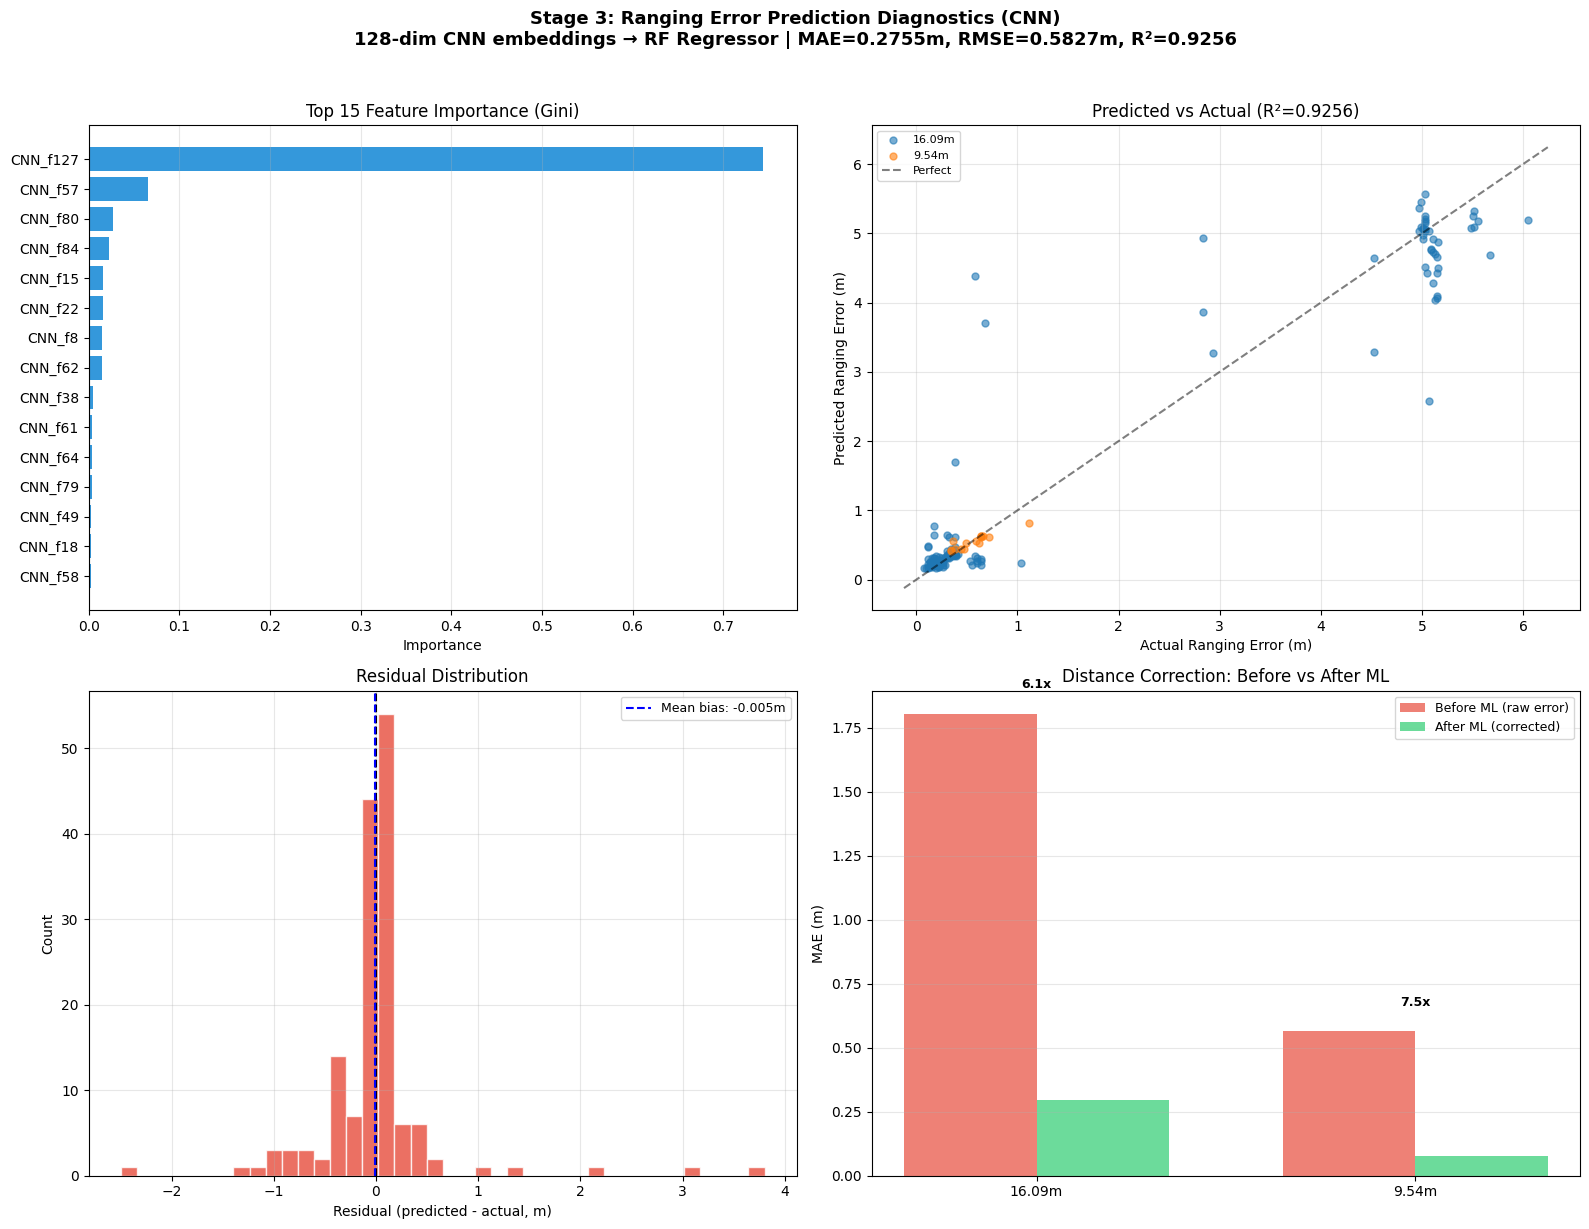


Distance Correction Summary (test set):
  Before ML:  MAE = 1.6815m  (raw hardware error)
  After ML:   MAE = 0.2755m  (corrected)
  Improvement: 6.1x lower error

Top 15 Feature Importance (ranked):
  CNN_f127                  0.7439
  CNN_f57                   0.0650
  CNN_f80                   0.0265
  CNN_f84                   0.0225
  CNN_f15                   0.0164
  CNN_f22                   0.0159
  CNN_f8                    0.0152
  CNN_f62                   0.0143
  CNN_f38                   0.0051
  CNN_f61                   0.0040
  CNN_f64                   0.0036
  CNN_f79                   0.0036
  CNN_f49                   0.0030
  CNN_f18                   0.0029
  CNN_f58                   0.0027


In [7]:
# ==========================================
# DIAGNOSTICS
# ==========================================
fig, axs = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.35, wspace=0.3)

# 1. Feature Importance (top 15 CNN dims)
ax = axs[0, 0]
importances = rf_model.feature_importances_
top_k = min(15, len(importances))
sorted_idx = np.argsort(importances)[-top_k:]
ax.barh(np.array(EMBEDDING_NAMES)[sorted_idx], importances[sorted_idx], color='#3498db')
ax.set_title(f"Top {top_k} Feature Importance (Gini)")
ax.set_xlabel("Importance")
ax.grid(True, alpha=0.3, axis='x')

# 2. Predicted vs Actual scatter
ax = axs[0, 1]
unique_test_groups = sorted(set(g_test))
for g in unique_test_groups:
    mask = g_test == g
    ax.scatter(y_test[mask], y_pred_test[mask], s=25, alpha=0.6, label=g)
lims = [min(y_test.min(), y_pred_test.min()) - 0.2,
        max(y_test.max(), y_pred_test.max()) + 0.2]
ax.plot(lims, lims, 'k--', lw=1.5, alpha=0.5, label='Perfect')
ax.set_xlabel('Actual Ranging Error (m)')
ax.set_ylabel('Predicted Ranging Error (m)')
ax.set_title(f'Predicted vs Actual (R²={test_r2:.4f})')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 3. Residual histogram
ax = axs[1, 0]
residuals = y_pred_test - y_test
ax.hist(residuals, bins=40, color='#e74c3c', edgecolor='white', alpha=0.8)
ax.axvline(0, color='black', ls='--', lw=1.5)
ax.axvline(residuals.mean(), color='blue', ls='--', lw=1.5,
           label=f'Mean bias: {residuals.mean():.3f}m')
ax.set_xlabel('Residual (predicted - actual, m)')
ax.set_ylabel('Count')
ax.set_title('Residual Distribution')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# 4. Per-scenario MAE — before vs after correction
ax = axs[1, 1]
before_maes = []
after_maes = []
labels_bar = []
for g in sorted(set(g_test)):
    mask = g_test == g
    before_mae = np.abs(y_test[mask]).mean()  # raw error
    corrected_error = (dh_test[mask] - y_pred_test[mask]) - dd_test[mask]
    after_mae = np.abs(corrected_error).mean()
    before_maes.append(before_mae)
    after_maes.append(after_mae)
    labels_bar.append(g)

x_pos = np.arange(len(labels_bar))
w = 0.35
ax.bar(x_pos - w/2, before_maes, w, color='#e74c3c', alpha=0.7, label='Before ML (raw error)')
ax.bar(x_pos + w/2, after_maes, w, color='#2ecc71', alpha=0.7, label='After ML (corrected)')
ax.set_xticks(x_pos)
ax.set_xticklabels(labels_bar)
ax.set_ylabel('MAE (m)')
ax.set_title('Distance Correction: Before vs After ML')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

for i in range(len(x_pos)):
    if before_maes[i] > 0:
        improvement = before_maes[i] / max(after_maes[i], 1e-6)
        ax.text(x_pos[i], max(before_maes[i], after_maes[i]) + 0.1,
                f'{improvement:.1f}x', ha='center', fontsize=9, fontweight='bold')

plt.suptitle(f'Stage 3: Ranging Error Prediction Diagnostics (CNN)\n'
             f'128-dim CNN embeddings → RF Regressor | '
             f'MAE={test_mae:.4f}m, RMSE={test_rmse:.4f}m, R²={test_r2:.4f}',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Overall correction summary
corrected_distances = dh_test - y_pred_test
corrected_errors = corrected_distances - dd_test
raw_errors = dh_test - dd_test

print(f"\n{'='*50}")
print(f"Distance Correction Summary (test set):")
print(f"{'='*50}")
print(f"  Before ML:  MAE = {np.abs(raw_errors).mean():.4f}m  (raw hardware error)")
print(f"  After ML:   MAE = {np.abs(corrected_errors).mean():.4f}m  (corrected)")
improvement = np.abs(raw_errors).mean() / max(np.abs(corrected_errors).mean(), 1e-6)
print(f"  Improvement: {improvement:.1f}x lower error")

# Top features
print(f"\nTop 15 Feature Importance (ranked):")
for feat, imp in sorted(zip(EMBEDDING_NAMES, importances), key=lambda x: -x[1])[:15]:
    print(f"  {feat:<25} {imp:.4f}")

---
## Section 8: Save Artifacts

In [9]:
# ==========================================
# SAVE ARTIFACTS
# ==========================================
joblib.dump(rf_model, "stage3_nlos_bias_rf.joblib")
print("Saved: stage3_nlos_bias_rf.joblib")

joblib.dump({
    "config": CONFIG,
    "embedding_dim": EMBEDDING_DIM,
    "embedding_names": EMBEDDING_NAMES,
    "feature_dim": FEATURE_DIM,
    "stage1_config": STAGE1_CONFIG,
    "encoder_class": "CNN_Classifier",
    "fp_conditioning": False,
    "filter_strategy": "mixture_geometric_morphological",
    "dominance_threshold": CONFIG["dominance_threshold"],
    "bounce_search_window": CONFIG["bounce_search_window"],
    "dominant_path_max_peaks": CONFIG["dominant_path_max_peaks"],
    "target": "ranging_error = Distance_hardware - d_direct",
    "correction": "d_corrected = d_hardware - predicted_error",
    "test_mae": test_mae,
    "test_rmse": test_rmse,
    "test_r2": test_r2,
    "note": "Stage 3 RF regressor trained on correctable NLOS samples only "
            "(bounce dominance >= threshold AND num_peaks <= 2). "
            "Input: 128-dim CNN embeddings. Output: predicted ranging error (meters). "
            "Correction: d_corrected = d_hardware - predicted_error.",
}, "stage3_config.joblib")
print("Saved: stage3_config.joblib")

print(f"\nDependency: stage1_cnn_best.pt (frozen CNN_Classifier encoder)")
print(f"Pipeline complete: Stage 1 → Stage 2 → Stage 3")

Saved: stage3_nlos_bias_rf.joblib
Saved: stage3_config.joblib

Dependency: stage1_cnn_best.pt (frozen CNN_Classifier encoder)
Pipeline complete: Stage 1 → Stage 2 → Stage 3


In [10]:
print("=" * 60)
print("Stage 3 — Summary (CNN)")
print("=" * 60)
print(f"Model artifact: stage3_nlos_bias_rf.joblib")
print(f"Config artifact: stage3_config.joblib")
print(f"Encoder dependency: stage1_cnn_best.pt (frozen CNN_Classifier)")
print()
print(f"Architecture: Frozen CNN_Classifier encoder → {FEATURE_DIM}-dim features → RF Regressor")
print(f"  CNN embeddings: {EMBEDDING_DIM}-dim (GAP over conv feature maps)")
print(f"  FP_AMPL conditioning: NONE (CIR only)")
print()
print(f"Data: {len(X_all)} correctable NLOS samples (filtered by mixture criteria)")
print(f"Target: ranging_error = Distance_hardware - d_direct (meters)")
print(f"Correction: d_corrected = d_hardware - predicted_error")
print()
print(f"Test MAE:   {test_mae:.4f}m")
print(f"Test RMSE:  {test_rmse:.4f}m")
print(f"Test R²:    {test_r2:.4f}")
print()
raw_mae = np.abs(dh_test - dd_test).mean()
corrected_mae = np.abs((dh_test - y_pred_test) - dd_test).mean()
print(f"Distance correction (test set):")
print(f"  Before ML: MAE = {raw_mae:.4f}m")
print(f"  After ML:  MAE = {corrected_mae:.4f}m")
print(f"  Improvement: {raw_mae/max(corrected_mae, 1e-6):.1f}x")
print()
print()
print("Pipeline: Stage 1 (CNN) → Stage 2 (CNN→RF→bounce ID) → Stage 3 (CNN→RF→error correction)")

Stage 3 — Summary (CNN)
Model artifact: stage3_nlos_bias_rf.joblib
Config artifact: stage3_config.joblib
Encoder dependency: stage1_cnn_best.pt (frozen CNN_Classifier)

Architecture: Frozen CNN_Classifier encoder → 128-dim features → RF Regressor
  CNN embeddings: 128-dim (GAP over conv feature maps)
  FP_AMPL conditioning: NONE (CIR only)

Data: 506 correctable NLOS samples (filtered by mixture criteria)
Target: ranging_error = Distance_hardware - d_direct (meters)
Correction: d_corrected = d_hardware - predicted_error

Test MAE:   0.2755m
Test RMSE:  0.5827m
Test R²:    0.9256

Distance correction (test set):
  Before ML: MAE = 1.6815m
  After ML:  MAE = 0.2755m
  Improvement: 6.1x

Unseen MAE:   1.9766m
Unseen RMSE:  2.2982m
Unseen R²:    -2.0804
Unseen improvement: 1.6x

Pipeline: Stage 1 (CNN) → Stage 2 (CNN→RF→bounce ID) → Stage 3 (CNN→RF→error correction)
